In [62]:
import pandas as pd
import numpy as np

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score, accuracy_score
import pickle #me permite guardar objetos de python
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree

from pickle import dump
import warnings

warnings.filterwarnings('ignore')

### Paso 1: Carga del conjunto de datos

In [63]:
df =  pd.read_csv('/workspaces/Antonio27M-machine-learning/data/processed/eda_insulina.csv')

In [64]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62,12.000000,43.0,27.2,0.580,24
711,5,126,78,27.000000,22.0,29.6,0.439,40
373,2,105,58,40.000000,94.0,34.9,0.225,25
46,1,146,56,20.536458,0.2,29.7,0.564,29
682,0,95,64,39.000000,105.0,44.6,0.366,22


### Paso 2: Construye un boosting

Comenzamos el análisis con sus valores por defecto, para luego aplicar GridSearchCV por modelo y encontrar el mejor resultado posible.

In [65]:

ada = AdaBoostClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier()
lgb = LGBMClassifier()


In [66]:
ada.fit(X_train, y_train), gb.fit(X_train, y_train), xgb.fit(X_train, y_train), lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

(AdaBoostClassifier(),
 GradientBoostingClassifier(),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 LGBMClassifier())

In [67]:
param_ada = {'n_estimators': [50, 100, 150], 'learning_rate': [0.1, 0.5, 1.0]}

grid_ada = GridSearchCV(AdaBoostClassifier(), param_ada, cv=5, scoring='accuracy', n_jobs=-1)
grid_ada.fit(X_train, y_train)

grid_ada.best_params_
grid_ada.best_score_


0.7703052112488339

In [68]:
param_gb = {'n_estimators': [50, 100, 150], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [2, 3, 4]}

grid_gb = GridSearchCV(GradientBoostingClassifier(),param_gb,cv=5,scoring='accuracy',n_jobs=-1)

grid_gb.fit(X_train, y_train)

grid_gb.best_params_
grid_gb.best_score_

0.767173130747701

In [69]:
param_xgb = {'eta': [0.1, 0.2, 0.3], 'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 150]}

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='mlogloss'), param_xgb, cv=5, scoring='accuracy', n_jobs=-1)

grid_xgb.fit(X_train, y_train)

grid_xgb.best_params_
grid_xgb.best_score_


0.7622817539650807

In [70]:
param_lgb = {'learning_rate': [0.05, 0.1, 0.2], 'n_estimators': [50, 100, 200], 'num_leaves': [15, 31, 63]}

grid_lgb = GridSearchCV(LGBMClassifier(), param_lgb, cv=5, scoring='accuracy', n_jobs=-1)

grid_lgb.fit(X_train, y_train)

grid_lgb.best_params_
grid_lgb.best_score_


[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 579
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 576
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Info] Number of 

0.7638677862188459

In [71]:
results = {'Modelo': ['AdaBoost', 'GradientBoosting', 'XGBoost', 'LightGBM'], 'Mejores Parámetros': [grid_ada.best_params_, grid_gb.best_params_, grid_xgb.best_params_, grid_lgb.best_params_],
    'Mejor Score CV': [grid_ada.best_score_, grid_gb.best_score_, grid_xgb.best_score_, grid_lgb.best_score_]}

df_results = pd.DataFrame(results)
df_results


,Modelo,Mejores Parámetros,Mejor Score CV
0,AdaBoost,"{'learning_rate': 1.0, 'n_estimators': 100}",0.770305
1,GradientBoosting,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.767173
2,XGBoost,"{'eta': 0.1, 'max_depth': 5, 'n_estimators': 50}",0.762282
3,LightGBM,"{'learning_rate': 0.05, 'n_estimators': 50, 'n...",0.763868


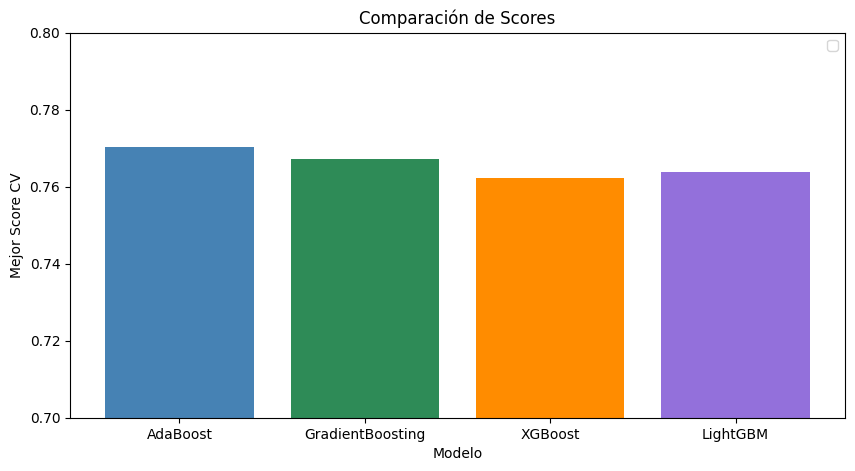

In [72]:
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']
plt.figure(figsize=(10, 5))
plt.bar(df_results['Modelo'], df_results['Mejor Score CV'], color=colors)
plt.xlabel('Modelo')
plt.ylabel('Mejor Score CV')
plt.title('Comparación de Scores')
plt.legend()
plt.ylim(0.7, 0.8)
plt.show()

### Observación: 

Hasta este punto el modelo AdaBoots tiene el mejor score que los demás modelos aunque la diferencias entre ellos es poca.

In [73]:
ada_y_pred_test = ada.predict(X_test)
gb_y_pred_test = gb.predict(X_test)
xgb_y_pred_test = xgb.predict(X_test)
lgb_y_pred_test = lgb.predict(X_test)

ada_y_pred_train = ada.predict(X_train)
gb_y_pred_train = gb.predict(X_train)
xgb_y_pred_train = xgb.predict(X_train)
lgb_y_pred_train = lgb.predict(X_train)

In [74]:
accuracy_train = (accuracy_score(y_train, ada_y_pred_train),
                  accuracy_score(y_train, gb_y_pred_train),
                  accuracy_score(y_train, xgb_y_pred_train),
                  accuracy_score(y_train, lgb_y_pred_train))
accuracy_test = (accuracy_score(y_test, ada_y_pred_test),
                 accuracy_score(y_test, gb_y_pred_test),
                 accuracy_score(y_test, xgb_y_pred_test),
                 accuracy_score(y_test, lgb_y_pred_test))

accuracy = pd.DataFrame(data=[accuracy_train, accuracy_test],
                        columns=['AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM'],
                        index=['Train set', 'Test set'])

accuracy

,AdaBoost,Gradient Boosting,XGBoost,LightGBM
Train set,0.806189,0.931596,1.00000,1.00000
Test set,0.779221,0.759740,0.74026,0.75974


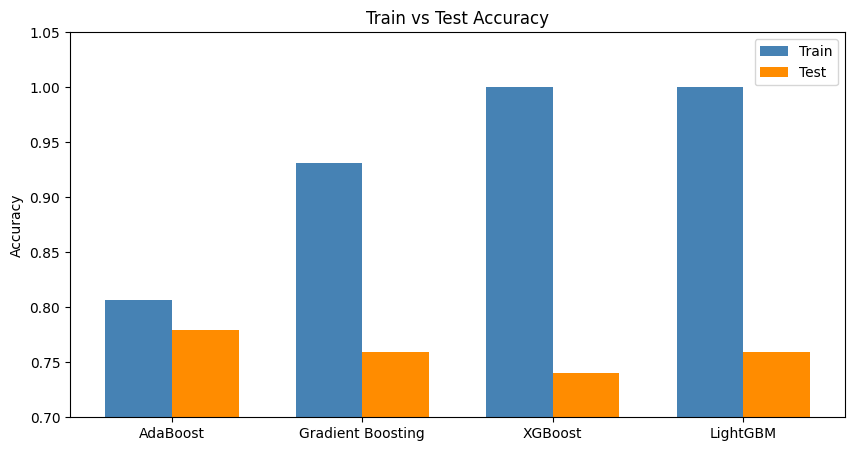

In [75]:
modelos = accuracy.columns
x = np.arange(len(modelos))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, accuracy.loc['Train set'], width, label='Train', color='steelblue')
plt.bar(x + width/2, accuracy.loc['Test set'], width, label='Test', color='darkorange')
plt.xticks(x, modelos)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.ylim(0.7, 1.05)
plt.legend()
plt.show()


### Paso 3: Guarda el modelo:

In [76]:
with open('../models/boosting_diabetes.pkl', 'wb') as f:
    pickle.dump(adaboost, f)

NameError: name 'adaboost' is not defined

### Paso 4: Analiza y compara los resultados de los modelos: 

Observando los resultados el modelo AdaBoost es el más apropiado para este caso, los demás demuestran sobreajuste al observar el Train vs. Test.